In [46]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [47]:
df=pd.read_csv("amazon_prime_titles.csv")

In [48]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [49]:
df.shape

(9668, 12)

In [50]:
df.drop(["show_id"],axis=1,inplace=True)
df.drop(["description"],axis=1,inplace=True)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy"


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          9668 non-null   object
 1   title         9668 non-null   object
 2   director      7585 non-null   object
 3   cast          8435 non-null   object
 4   country       672 non-null    object
 5   date_added    155 non-null    object
 6   release_year  9668 non-null   int64 
 7   rating        9331 non-null   object
 8   duration      9668 non-null   object
 9   listed_in     9668 non-null   object
dtypes: int64(1), object(9)
memory usage: 755.4+ KB


In [52]:
df.isnull().sum()

type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
dtype: int64

In [53]:
df["director"].fillna("Unavailable",inplace=True)
df["cast"].fillna("Unavailable",inplace=True)
df["country"].fillna("Unavailable",inplace=True)
df["date_added"]=df["date_added"].ffill()
df["rating"]=df["rating"].fillna(df["rating"].mode()[0])

C:\Users\nitti\AppData\Local\Temp\ipykernel_25176\1315463054.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unavailable",inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_25176\1315463054.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [54]:
df["date_added"].unique()

array(['March 30, 2021', 'April 1, 2021', 'April 4, 2021',
       'April 10, 2021', 'April 17, 2021', 'April 24, 2021',
       'May 2, 2021', 'June 3, 2021', 'April 13, 2021', 'April 20, 2021',
       'April 26, 2021', 'April 27, 2021', 'April 30, 2021',
       'May 1, 2021', 'May 9, 2021', 'May 11, 2021', 'May 12, 2021',
       'May 13, 2021', 'May 18, 2021', 'May 19, 2021', 'May 22, 2021',
       'May 24, 2021', 'May 29, 2021', 'June 4, 2021', 'June 11, 2021',
       'June 12, 2021', 'June 15, 2021', 'June 18, 2021', 'June 20, 2021',
       'June 21, 2021', 'June 22, 2021', 'June 23, 2021', 'June 24, 2021',
       'June 25, 2021', 'June 26, 2021', 'June 29, 2021', 'July 1, 2021',
       'July 3, 2021', 'July 8, 2021', 'July 12, 2021', 'July 16, 2021',
       'July 17, 2021', 'July 20, 2021', 'July 23, 2021', 'July 24, 2021',
       'July 26, 2021', 'July 27, 2021', 'August 1, 2021',
       'August 4, 2021', 'August 6, 2021', 'August 14, 2021',
       'August 15, 2021', 'August 16, 20

In [55]:
df["date_added"]=pd.to_datetime(df["date_added"])

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          9668 non-null   object        
 1   title         9668 non-null   object        
 2   director      9668 non-null   object        
 3   cast          9668 non-null   object        
 4   country       9668 non-null   object        
 5   date_added    9668 non-null   datetime64[ns]
 6   release_year  9668 non-null   int64         
 7   rating        9668 non-null   object        
 8   duration      9668 non-null   object        
 9   listed_in     9668 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 755.4+ KB


In [57]:
# top 10 directors with most directed values 
filtered_directors=df[df["director"] != "Unavailable"]
top_directors=filtered_directors["director"].value_counts().head(10)
top_directors

director
Mark Knight              113
Cannis Holder             61
Moonbug Entertainment     37
Jay Chapman               34
Arthur van Merwijk        30
Manny Rodriguez           22
John English              20
1                         16
Brian Volk-Weiss          15
Baeble Music              14
Name: count, dtype: int64

C:\Users\nitti\AppData\Local\Temp\ipykernel_25176\374711507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values,y=top_directors.index,palette="plasma")


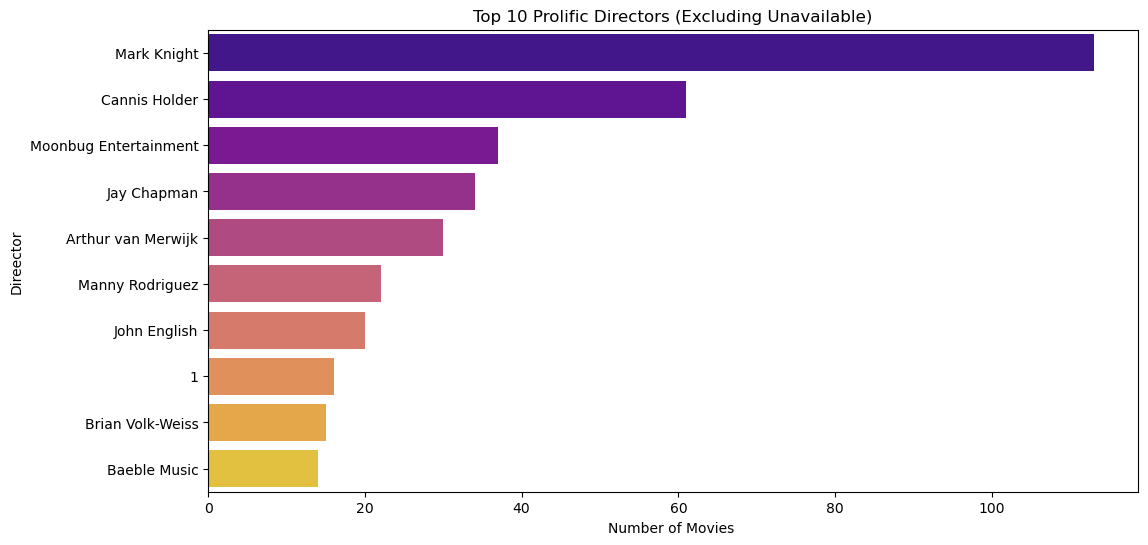

In [58]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_directors.values,y=top_directors.index,palette="plasma")
plt.title("Top 10 Prolific Directors (Excluding Unavailable)")
plt.xlabel("Number of Movies ")
plt.ylabel("Direector")
plt.show()

In [59]:
filtered_actors=df[df["cast"] != "Unavailable"]
top_actors=filtered_actors["cast"].value_counts().head(10)
top_actors

cast
Maggie Binkley                      56
1                                   34
Anne-Marie Newland                  24
Cassandra Peterson                  21
Grace Tamayo, Erin Webbs            17
Gene Autry, Champion, Gail Davis    12
Stevin John                         11
LB, Aaron Michael                    9
Gallagher                            9
Eddie Izzard                         9
Name: count, dtype: int64

C:\Users\nitti\AppData\Local\Temp\ipykernel_25176\1659763272.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values,y=top_actors.index,palette="plasma")


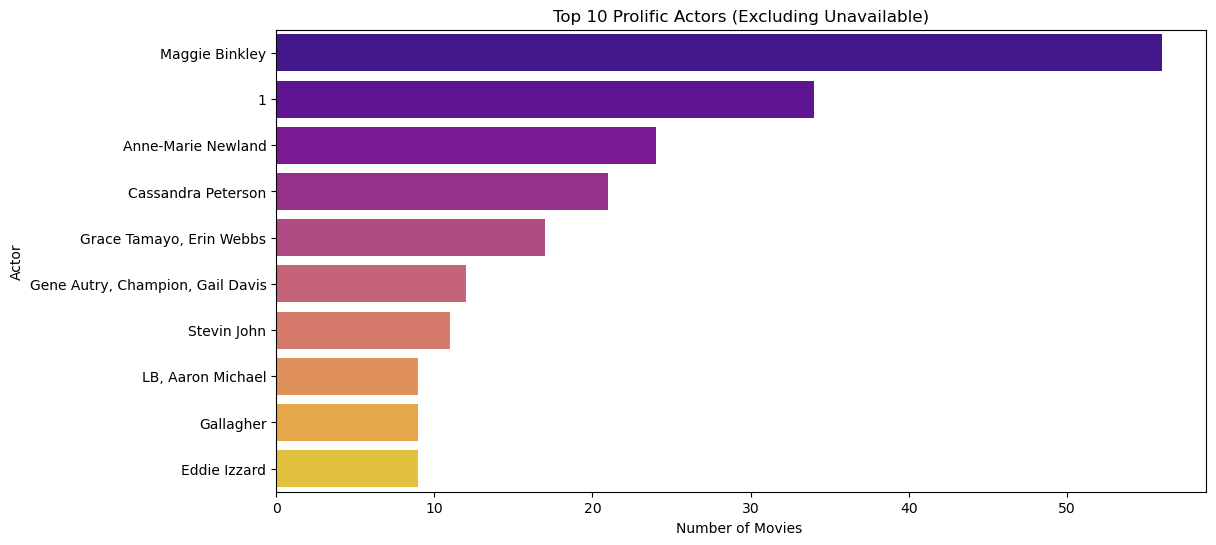

In [60]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_actors.values,y=top_actors.index,palette="plasma")
plt.title("Top 10 Prolific Actors (Excluding Unavailable)")
plt.xlabel("Number of Movies ")
plt.ylabel("Actor")
plt.show()

In [61]:
filtered_country=df[df["country"] != "Unavailable"]
top_country=filtered_country["country"].value_counts().head(10)
top_country

country
United States                    253
India                            229
United Kingdom                    28
Canada                            16
United Kingdom, United States     12
Spain                              8
Italy                              8
Canada, United States              7
United States, United Kingdom      6
Germany                            5
Name: count, dtype: int64

C:\Users\nitti\AppData\Local\Temp\ipykernel_25176\3232057467.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_country.values,y=top_country.index,palette="plasma")


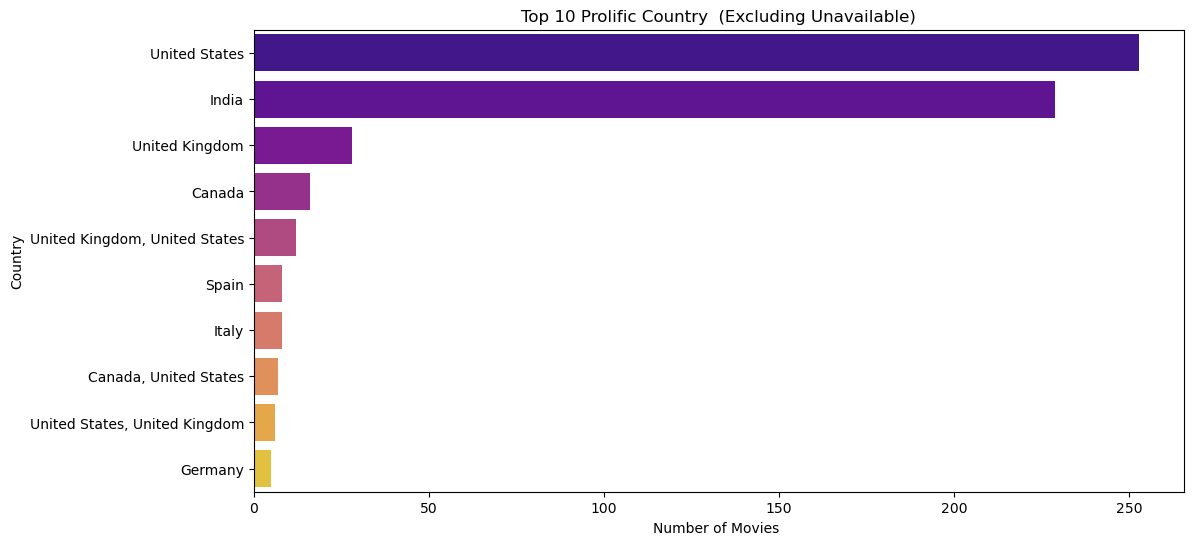

In [62]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_country.values,y=top_country.index,palette="plasma")
plt.title("Top 10 Prolific Country  (Excluding Unavailable)")
plt.xlabel("Number of Movies ")
plt.ylabel("Country")
plt.show()

C:\Users\nitti\AppData\Local\Temp\ipykernel_25176\1767609609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="type",palette="plasma")


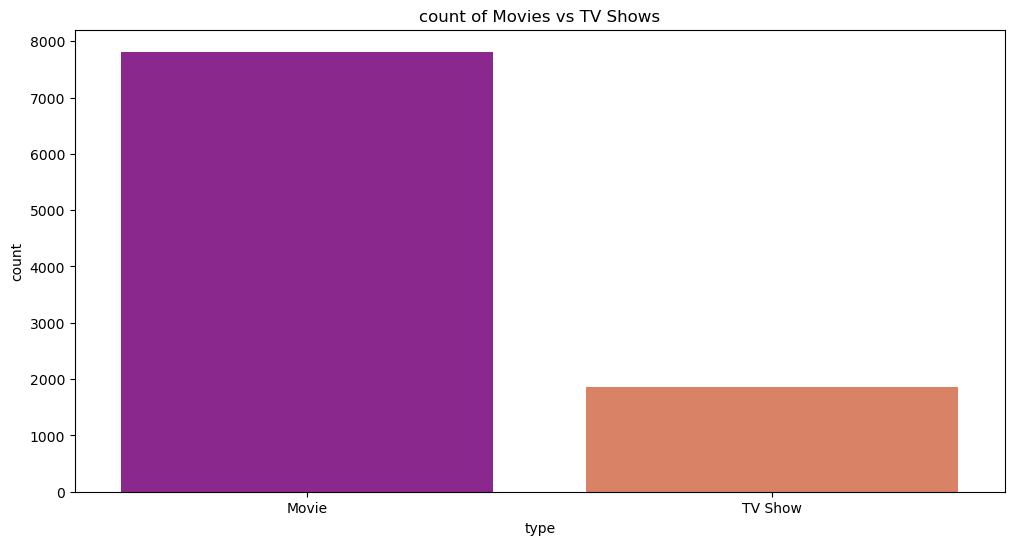

In [63]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="type",palette="plasma")
plt.title("count of Movies vs TV Shows")
plt.show()

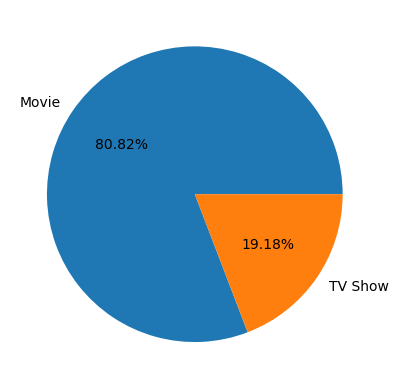

In [64]:
plt.pie(df["type"].value_counts(),labels=df["type"].value_counts().index,autopct="%1.2f%%")
plt.show()

In [65]:
df["rating"].unique()

array(['13+', 'ALL', '18+', 'R', 'TV-Y', 'TV-Y7', 'NR', '16+', 'TV-PG',
       '7+', 'TV-14', 'TV-NR', 'TV-G', 'PG-13', 'TV-MA', 'G', 'PG',
       'NC-17', 'UNRATED', '16', 'AGES_16_', 'AGES_18_', 'ALL_AGES',
       'NOT_RATE'], dtype=object)

In [66]:
df.groupby("type")["rating"].value_counts()

type     rating  
Movie    13+         2180
         16+         1272
         18+         1097
         R           1010
         ALL          988
         PG-13        393
         7+           288
         PG           253
         NR           194
         G             93
         UNRATED       33
         AGES_18_       3
         NC-17          3
         NOT_RATE       3
         AGES_16_       2
         16             1
         ALL_AGES       1
TV Show  ALL          280
         16+          275
         13+          274
         TV-14        208
         TV-PG        169
         18+          146
         TV-NR        105
         7+            97
         TV-G          81
         TV-MA         77
         TV-Y          74
         TV-Y7         39
         NR            29
Name: count, dtype: int64

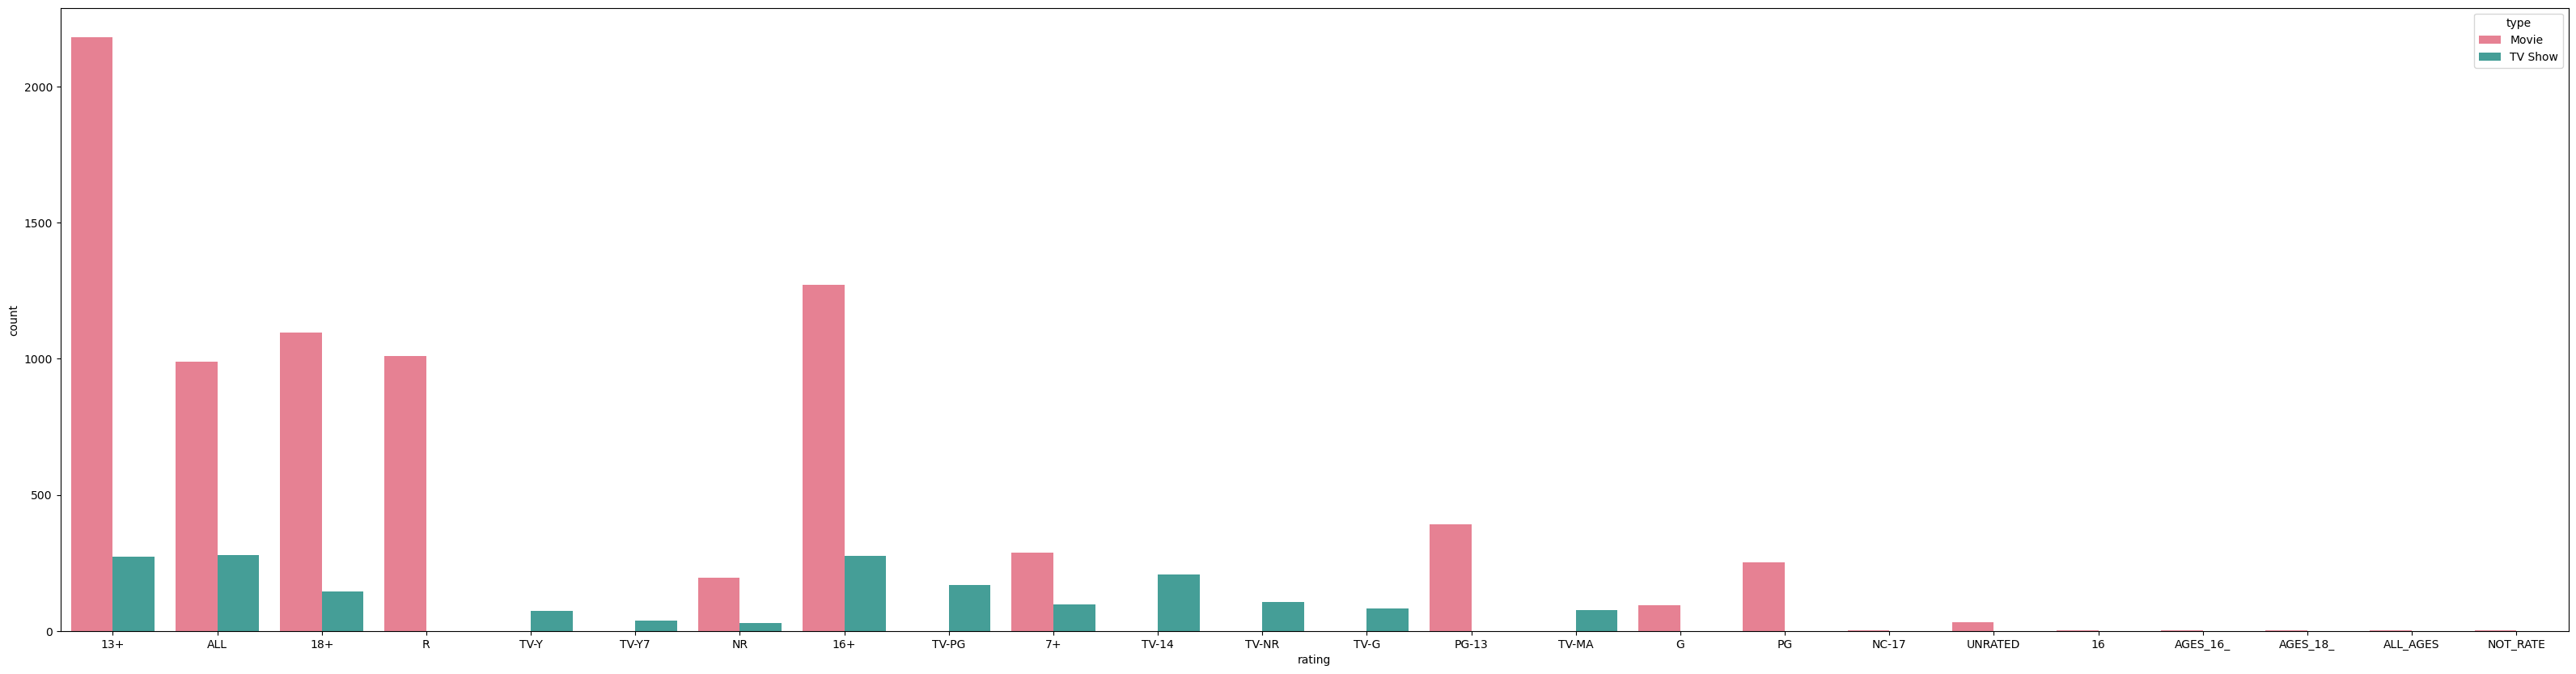

In [67]:
plt.figure(figsize=(40,10))
sns.countplot(x="rating",data=df,hue="type",palette="husl")
plt.show()

In [68]:
filtered_country=df[df["country"] != "Unavailable"]
country_counts=filtered_country["country"].value_counts()
country_counts

country
United States                                               253
India                                                       229
United Kingdom                                               28
Canada                                                       16
United Kingdom, United States                                12
                                                           ... 
United States, Mexico                                         1
United States, Germany, Japan, United Kingdom, Hong Kong      1
Italy, Canada                                                 1
France, Belgium                                               1
Italy, Spain                                                  1
Name: count, Length: 86, dtype: int64

In [69]:
top_countries=country_counts.nlargest(3).index
top_countries   # yha per top 3 country

Index(['United States', 'India', 'United Kingdom'], dtype='object', name='country')

In [70]:
df_top_countries=filtered_country[filtered_country["country"].isin(top_countries)]
df_top_countries  # yha per top 3 country ka data nikala hai 

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45 min,"Drama, Fantasy"
5,Movie,Living With Dinosaurs,Paul Weiland,"Gregory Chisholm, Juliet Stevenson, Brian Hens...",United Kingdom,2021-03-30,1989,13+,52 min,"Fantasy, Kids"
...,...,...,...,...,...,...,...,...,...,...
9604,Movie,Bride Wars,Gary Winick,"Kate Hudson, Anne Hathaway, Kristen Johnston, ...",United States,2021-10-08,2009,PG,89 min,Comedy
9614,Movie,What Happens in Vegas,Tom Vaughan,"Cameron Diaz, Ashton Kutcher, Rob Corddry, ...",United States,2021-10-08,2008,PG-13,99 min,Comedy
9641,Movie,Marley & Me,David Frankel,"Owen Wilson, Jennifer Aniston",United States,2021-10-10,2008,PG,116 min,"Comedy, Drama, Kids"
9643,Movie,Love & Other Drugs,Edward Zwick,"K K, Jake Gyllenhaal, Anne Hathaway, Oliver Pl...",United States,2021-10-10,2010,R,112 min,"Comedy, Drama"


C:\Users\nitti\AppData\Local\Temp\ipykernel_25176\269435873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top_countries,x="country",palette="husl")


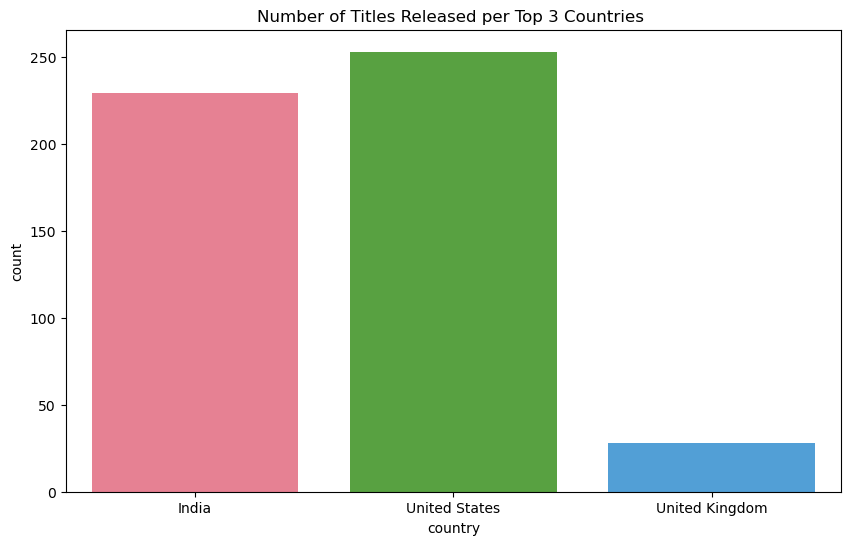

In [71]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_countries,x="country",palette="husl")
plt.title("Number of Titles Released per Top 3 Countries ")
plt.show()

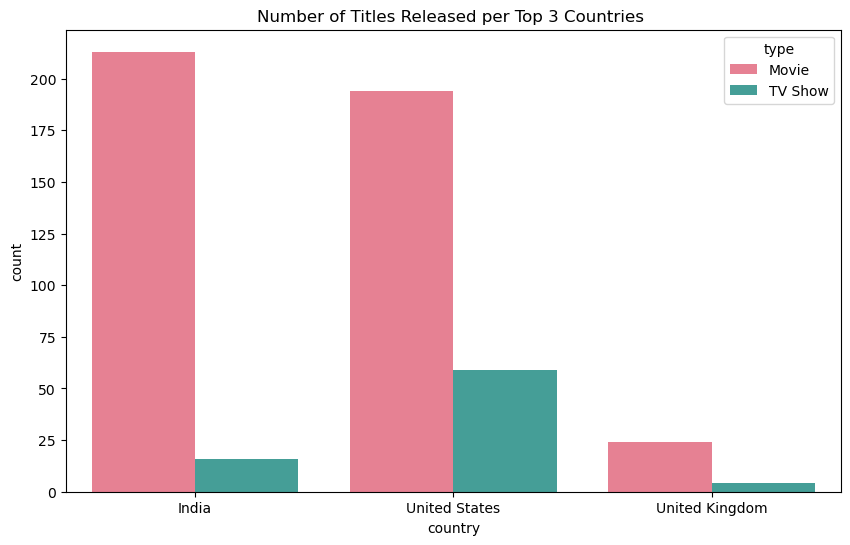

In [72]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_countries,x="country",hue="type",palette="husl")
plt.title("Number of Titles Released per Top 3 Countries ")
plt.show()

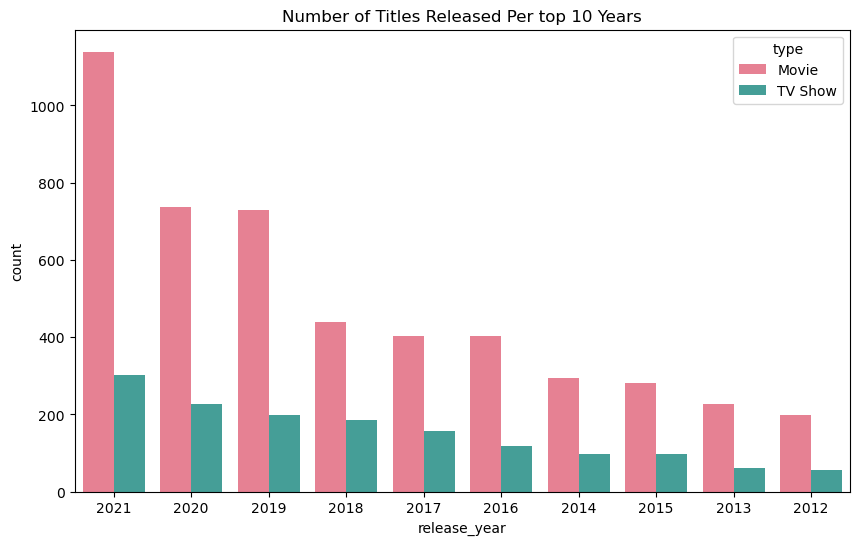

In [76]:
year_counts=df["release_year"].value_counts()
top_years=year_counts.nlargest(10).index
df_top_years=df[df["release_year"].isin(top_years)]
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_years,x= "release_year",hue="type",palette="husl",order=top_years)
plt.title("Number of Titles Released Per top 10 Years")
plt.show()

In [74]:
df_top_years

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary
6,Movie,Hired Gun,Fran Strine,"Alice Cooper, Liberty DeVitto, Ray Parker Jr.,...",United States,2021-03-30,2017,13+,98 min,"Documentary, Special Interest"
...,...,...,...,...,...,...,...,...,...,...
9657,Movie,A Place at the Table,"Kristi Jacobson, Lori Silverbush","Jeff Bridges, Tom Colicchio",Unavailable,2021-10-10,2013,PG,84 min,"Documentary, Special Interest"
9660,Movie,The Man in the Hat,"John-Paul Davidson, Stephen Warbeck","Ciaran Hinds, Stephen Dillane, Maïwenn",Unavailable,2021-10-10,2021,13+,96 min,Comedy
9662,Movie,River,Emily Skye,"Mary Cameron Rogers, Alexandra Rose, Rob Marsh...",Unavailable,2021-10-10,2021,16+,93 min,"Drama, Science Fiction, Suspense"
9664,TV Show,Planet Patrol,Unavailable,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",Unavailable,2021-10-10,2018,13+,4 Seasons,TV Shows


In [77]:
df["Genres"]=df["listed_in"].apply(lambda x:x.split(" "))
df["Genres"]

0                  [Comedy,, Drama]
1           [Drama,, International]
2       [Action,, Drama,, Suspense]
3                     [Documentary]
4                 [Drama,, Fantasy]
                   ...             
9663                       [Comedy]
9664                    [TV, Shows]
9665                       [Action]
9666               [Drama,, Sports]
9667    [Action,, Drama,, Suspense]
Name: Genres, Length: 9668, dtype: object

C:\Users\nitti\AppData\Local\Temp\ipykernel_25176\2695587233.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=genres_exploded,y="Genres",order=genres_exploded["Genres"].value_counts().index,palette="husl")


Text(0.5, 1.0, 'Distribution of Genres ')

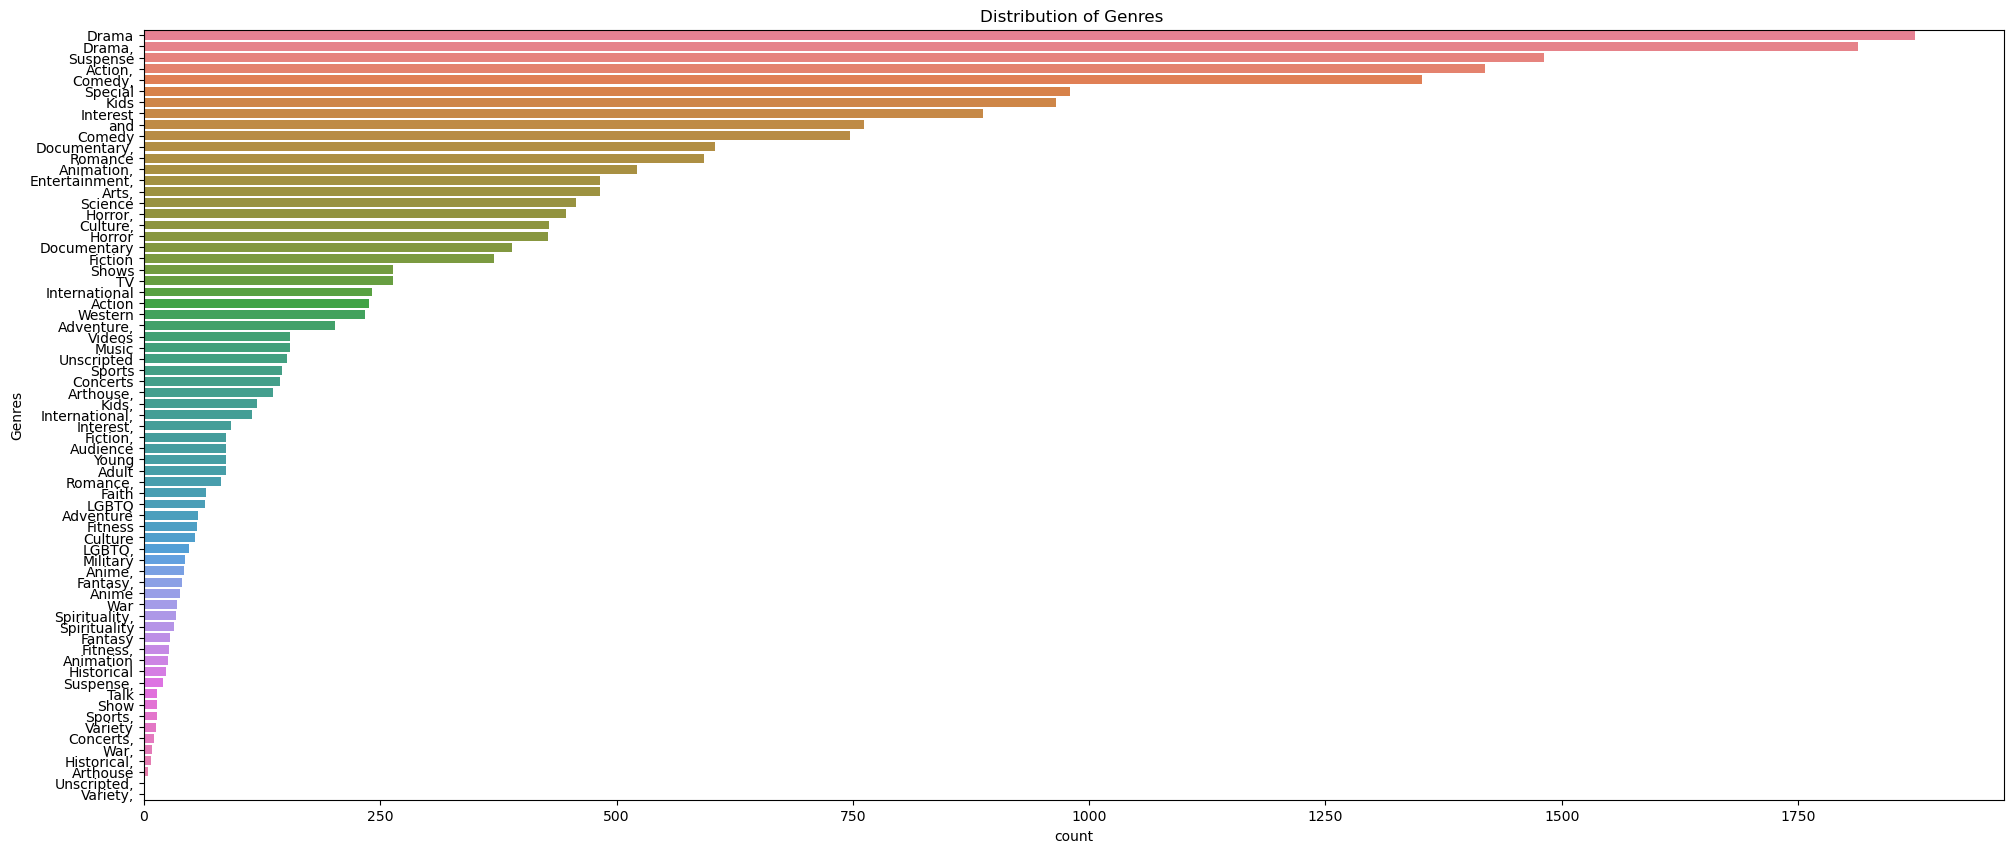

In [80]:
genres_exploded=df.explode("Genres")
plt.figure(figsize=(24,10))
sns.countplot(data=genres_exploded,y="Genres",order=genres_exploded["Genres"].value_counts().index,palette="husl")
plt.title("Distribution of Genres ")

In [81]:
df["duration"].unique()

array(['113 min', '110 min', '74 min', '69 min', '45 min', '52 min',
       '98 min', '131 min', '87 min', '92 min', '88 min', '93 min',
       '94 min', '46 min', '96 min', '1 Season', '104 min', '62 min',
       '50 min', '3 Seasons', '2 Seasons', '86 min', '36 min', '37 min',
       '103 min', '9 min', '18 min', '14 min', '20 min', '19 min',
       '22 min', '60 min', '6 min', '54 min', '5 min', '84 min',
       '126 min', '125 min', '109 min', '89 min', '85 min', '56 min',
       '40 min', '111 min', '33 min', '34 min', '95 min', '99 min',
       '78 min', '4 Seasons', '77 min', '55 min', '53 min', '115 min',
       '58 min', '49 min', '135 min', '91 min', '64 min', '59 min',
       '48 min', '122 min', '90 min', '102 min', '65 min', '114 min',
       '136 min', '70 min', '138 min', '100 min', '480 min', '4 min',
       '30 min', '152 min', '68 min', '57 min', '7 Seasons', '31 min',
       '151 min', '149 min', '9 Seasons', '141 min', '121 min', '79 min',
       '140 min', '51 min'

In [82]:
df["duration"]=df["duration"].apply(lambda x:int(x.split()[0]))

In [84]:
df["duration"].unique()

array([113, 110,  74,  69,  45,  52,  98, 131,  87,  92,  88,  93,  94,
        46,  96,   1, 104,  62,  50,   3,   2,  86,  36,  37, 103,   9,
        18,  14,  20,  19,  22,  60,   6,  54,   5,  84, 126, 125, 109,
        89,  85,  56,  40, 111,  33,  34,  95,  99,  78,   4,  77,  55,
        53, 115,  58,  49, 135,  91,  64,  59,  48, 122,  90, 102,  65,
       114, 136,  70, 138, 100, 480,  30, 152,  68,  57,   7,  31, 151,
       149, 141, 121,  79, 140,  51, 106,  75,  27, 107, 108,  38, 157,
        43, 118, 139, 112,  15,  72, 116, 142,  71,  42,  81,  32,  66,
       127, 159,  67,  29, 132, 101, 164,  73,  61,  80,  83,  44, 120,
        26,  97,  23, 105,  82,  11, 148, 161, 123,   0, 124, 143,  35,
        47, 170, 146, 601,  24,  21, 154, 128, 133, 153, 119,  63, 169,
       174, 144, 137,  76,  39,   8,  12, 134, 163, 145, 162,  41, 147,
       155, 117, 167,  28,  25, 180, 541, 240, 129, 178, 171, 172, 173,
        10, 166, 160, 130, 479,  13,  17,  16, 158, 183, 150, 48

In [85]:
df_movies=df[df["type"]=="Movie"].copy()
df_tv_shows=df[df["type"]=="TV Show"].copy()

In [86]:
df_movies

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,Genres
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113,"Comedy, Drama","[Comedy,, Drama]"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110,"Drama, International","[Drama,, International]"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74,"Action, Drama, Suspense","[Action,, Drama,, Suspense]"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69,Documentary,[Documentary]
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45,"Drama, Fantasy","[Drama,, Fantasy]"
...,...,...,...,...,...,...,...,...,...,...,...
9660,Movie,The Man in the Hat,"John-Paul Davidson, Stephen Warbeck","Ciaran Hinds, Stephen Dillane, Maïwenn",Unavailable,2021-10-10,2021,13+,96,Comedy,[Comedy]
9662,Movie,River,Emily Skye,"Mary Cameron Rogers, Alexandra Rose, Rob Marsh...",Unavailable,2021-10-10,2021,16+,93,"Drama, Science Fiction, Suspense","[Drama,, Science, Fiction,, Suspense]"
9663,Movie,Pride Of The Bowery,Joseph H. Lewis,"Leo Gorcey, Bobby Jordan",Unavailable,2021-10-10,1940,7+,60,Comedy,[Comedy]
9665,Movie,Outpost,Steve Barker,"Ray Stevenson, Julian Wadham, Richard Brake, M...",Unavailable,2021-10-10,2008,R,90,Action,[Action]
